# KITTI ORB / DSO / SVO SLAM Comparison

This notebook is the current interactive result viewer for the repository. It reads the generated benchmark JSON files, trajectory plots, DSO diagnostics, and DSO ablation output.

Compared baselines:

- ORB-SLAM2-inspired stereo SLAM
- DSO-inspired direct sparse stereo SLAM
- SVO-style semi-direct stereo visual odometry/SLAM

These are reproducible Python research baselines, not official full C++ paper-level reproductions. The manifest field `implementation_manifest.paper_level_claim` should remain `false`.


## 1. Paths and Helpers

The notebook reads these existing result files by default:

- `results/tri_slam_20/benchmark_seq00.json`
- `results/tri_slam_100/benchmark_seq00.json`
- `results/dso_ablation_100/dso_ablation_seq00.json`


In [8]:
from pathlib import Path
import json
import math
from IPython.display import display, Markdown, Image

ROOT = Path('.')
RESULTS = ROOT / 'results'
BENCHMARKS = {
    '20 frames': RESULTS / 'tri_slam_20' / 'benchmark_seq00.json',
    '100 frames': RESULTS / 'tri_slam_100' / 'benchmark_seq00.json',
}
ABLATION_PATH = RESULTS / 'dso_ablation_100' / 'dso_ablation_seq00.json'


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def fmt(value, digits: int = 4) -> str:
    if value is None:
        return 'null'
    if isinstance(value, float):
        if not math.isfinite(value):
            return 'null'
        return f'{value:.{digits}f}'
    return str(value)


def markdown_table(headers, rows) -> str:
    header_line = '| ' + ' | '.join(headers) + ' |'
    sep_line = '| ' + ' | '.join(['---'] * len(headers)) + ' |'
    body = ['| ' + ' | '.join(str(item) for item in row) + ' |' for row in rows]
    return '\n'.join([header_line, sep_line, *body])


def algo_result_rows(summary: dict):
    rows = []
    for key, name in [('orb', 'ORB'), ('dso', 'DSO'), ('svo', 'SVO')]:
        item = summary.get(key, {})
        runtime = item.get('runtime', {})
        robust = item.get('robustness', {})
        rows.append([
            name,
            fmt(item.get('ate_rmse_m')),
            f"{fmt(runtime.get('avg_ms'), 2)} / {fmt(runtime.get('median_ms'), 2)} / {fmt(runtime.get('p95_ms'), 2)}",
            fmt(item.get('wall_time_s'), 2),
            fmt(item.get('keyframes'), 0),
            fmt(robust.get('tracking_failures', 0), 0),
            fmt(robust.get('fallbacks_used', 0), 0),
            fmt(robust.get('loop_closures', 0), 0),
        ])
    return rows


def robustness_rows(summary: dict):
    rows = []
    for key, name in [('orb', 'ORB'), ('dso', 'DSO'), ('svo', 'SVO')]:
        robust = summary.get(key, {}).get('robustness', {})
        rows.append([
            name,
            fmt(robust.get('frames_processed'), 0),
            fmt(robust.get('mean_valid_projected_points', robust.get('mean_tracked_points')), 2),
            fmt(robust.get('median_valid_projected_points'), 2),
            fmt(robust.get('mean_inlier_ratio'), 4),
            fmt(robust.get('motion_gate_rejections', 0), 0),
            fmt(robust.get('low_projection_rejections', 0), 0),
        ])
    return rows


## 2. Load Benchmark JSON and Check Manifest

If an assertion fails, the result JSON or reproduction claim has drifted from the intended project boundary.


In [9]:
benchmarks = {label: load_json(path) for label, path in BENCHMARKS.items()}

for label, summary in benchmarks.items():
    manifest = summary['implementation_manifest']
    assert manifest['paper_level_claim'] is False, label
    for algo in ['orb', 'dso', 'svo']:
        assert algo in manifest['algorithms'], f'{label}: missing {algo} in manifest'
        assert algo in summary, f'{label}: missing {algo} result'

for label, path in BENCHMARKS.items():
    display(Markdown(f'- **{label}**: `{path}`'))


- **20 frames**: `results\tri_slam_20\benchmark_seq00.json`

- **100 frames**: `results\tri_slam_100\benchmark_seq00.json`

## 3. Algorithm Result Tables

ATE, runtime, wall time, keyframe count, and robustness counters are read directly from `benchmark_seq00.json`.


In [10]:
headers = [
    'Algorithm',
    'ATE RMSE (m)',
    'Runtime avg / median / p95 (ms)',
    'Wall time (s)',
    'Keyframes',
    'Tracking failures',
    'Fallbacks',
    'Loop closures',
]

for label, summary in benchmarks.items():
    display(Markdown(f'### Sequence {summary["sequence"]}, {label}, alignment={summary["alignment"]}'))
    display(Markdown(markdown_table(headers, algo_result_rows(summary))))


### Sequence 00, 20 frames, alignment=origin

| Algorithm | ATE RMSE (m) | Runtime avg / median / p95 (ms) | Wall time (s) | Keyframes | Tracking failures | Fallbacks | Loop closures |
| --- | --- | --- | --- | --- | --- | --- | --- |
| ORB | 0.9367 | 6078.94 / 91.78 / 28712.37 | 121.92 | 7 | 0 | 0 | 0 |
| DSO | 1.6427 | 610.33 / 386.47 / 1216.79 | 12.16 | 7 | 0 | 0 | 0 |
| SVO | 1.1066 | 118.25 / 163.89 / 189.46 | 2.76 | 12 | 0 | 0 | 0 |

### Sequence 00, 100 frames, alignment=origin

| Algorithm | ATE RMSE (m) | Runtime avg / median / p95 (ms) | Wall time (s) | Keyframes | Tracking failures | Fallbacks | Loop closures |
| --- | --- | --- | --- | --- | --- | --- | --- |
| ORB | 2.1349 | 108781.18 / 149.90 / 63623.81 | 10881.14 | 34 | 0 | 0 | 0 |
| DSO | 87.8995 | 441.29 / 261.63 / 1250.25 | 44.97 | 40 | 6 | 6 | 0 |
| SVO | 2.2858 | 69.35 / 82.55 / 104.25 | 7.87 | 75 | 0 | 0 | 0 |

## 4. Robustness Summary

ORB does not expose direct-method projected point and inlier-ratio diagnostics, so those cells may appear as `null`.


In [11]:
headers = [
    'Algorithm',
    'Frames',
    'Mean valid/tracked points',
    'Median valid points',
    'Mean inlier ratio',
    'Motion gate rejects',
    'Low projection rejects',
]

for label, summary in benchmarks.items():
    display(Markdown(f'### Robustness, {label}'))
    display(Markdown(markdown_table(headers, robustness_rows(summary))))


### Robustness, 20 frames

| Algorithm | Frames | Mean valid/tracked points | Median valid points | Mean inlier ratio | Motion gate rejects | Low projection rejects |
| --- | --- | --- | --- | --- | --- | --- |
| ORB | 20 | null | null | null | 0 | 0 |
| DSO | 20 | 623.11 | 610.00 | 0.7049 | 0 | 0 |
| SVO | 20 | 904.00 | 939.00 | 0.7767 | 0 | 0 |

### Robustness, 100 frames

| Algorithm | Frames | Mean valid/tracked points | Median valid points | Mean inlier ratio | Motion gate rejects | Low projection rejects |
| --- | --- | --- | --- | --- | --- | --- |
| ORB | 100 | null | null | null | 0 | 0 |
| DSO | 100 | 1097.41 | 1097.00 | 0.7328 | 5 | 0 |
| SVO | 100 | 1030.49 | 1036.00 | 0.7289 | 0 | 0 |

## 5. Trajectory and DSO Diagnostic Plots

The trajectory plots include ground truth, ORB, DSO, and SVO estimates.


### `results\tri_slam_20\benchmark_trajectory_seq00.png`

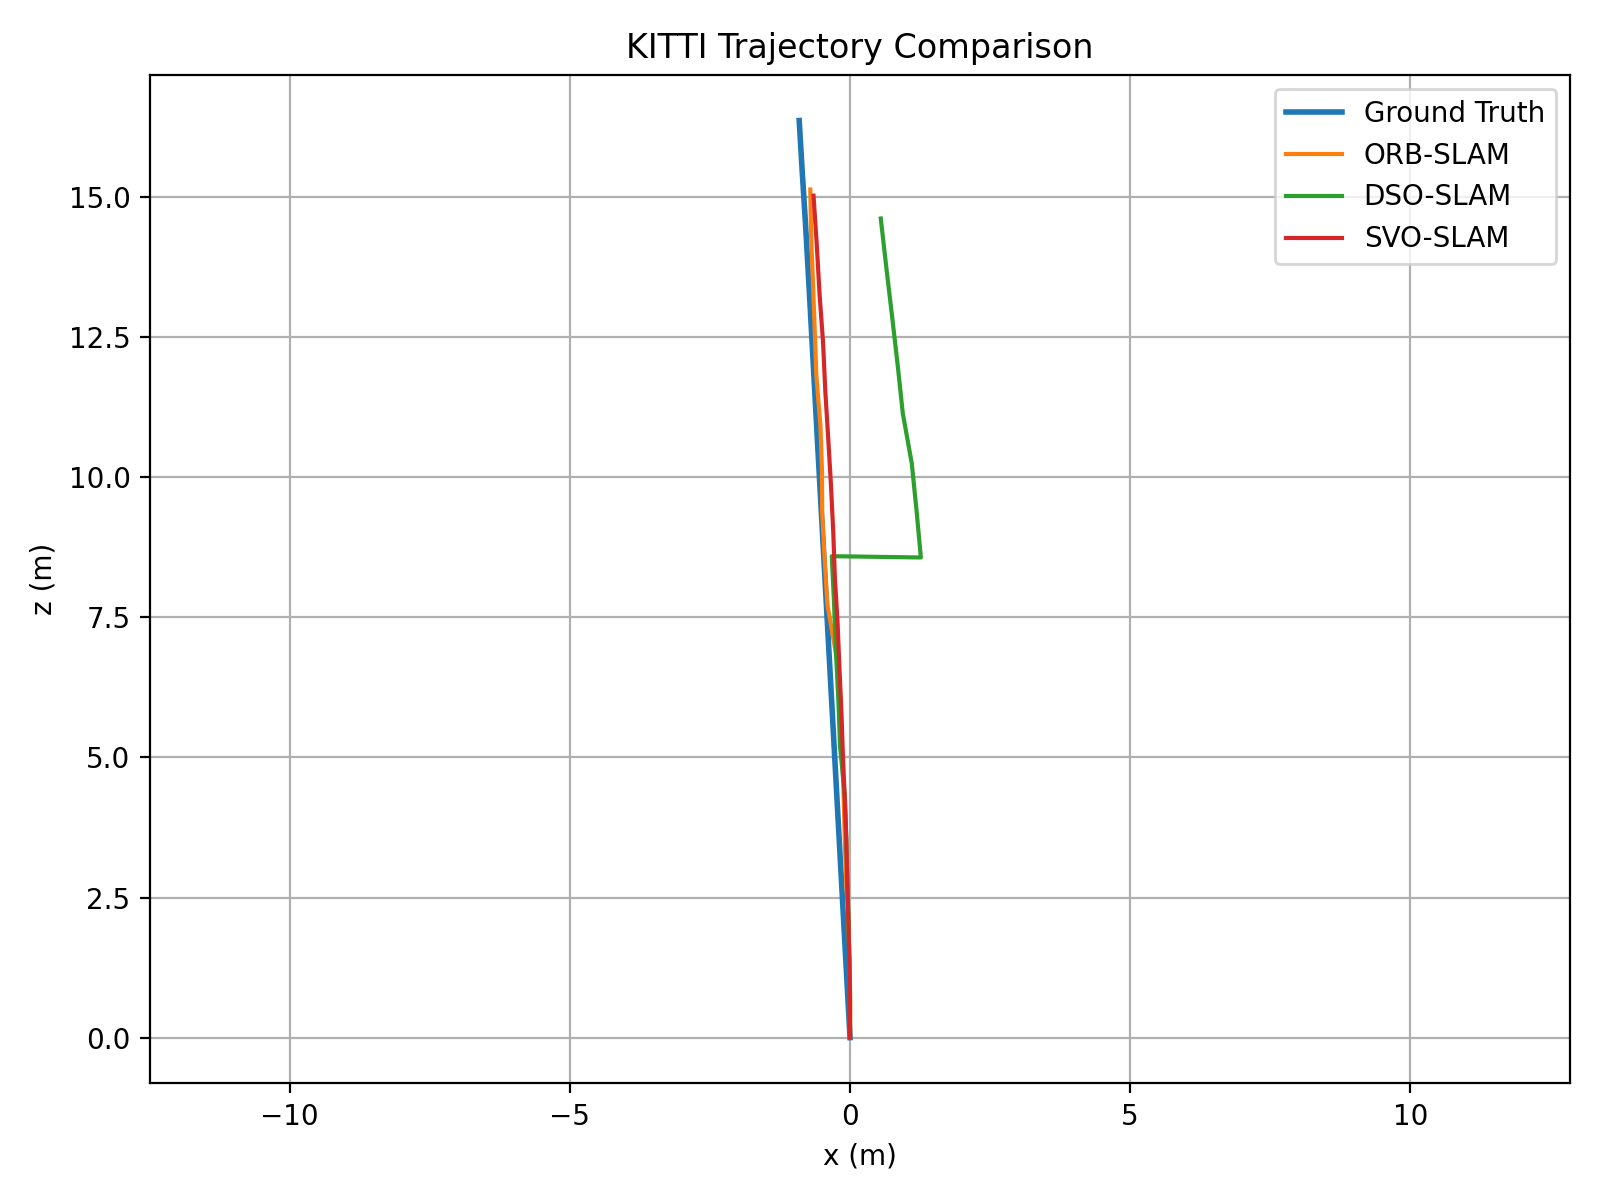

### `results\tri_slam_20\dso_diagnostics_seq00.png`

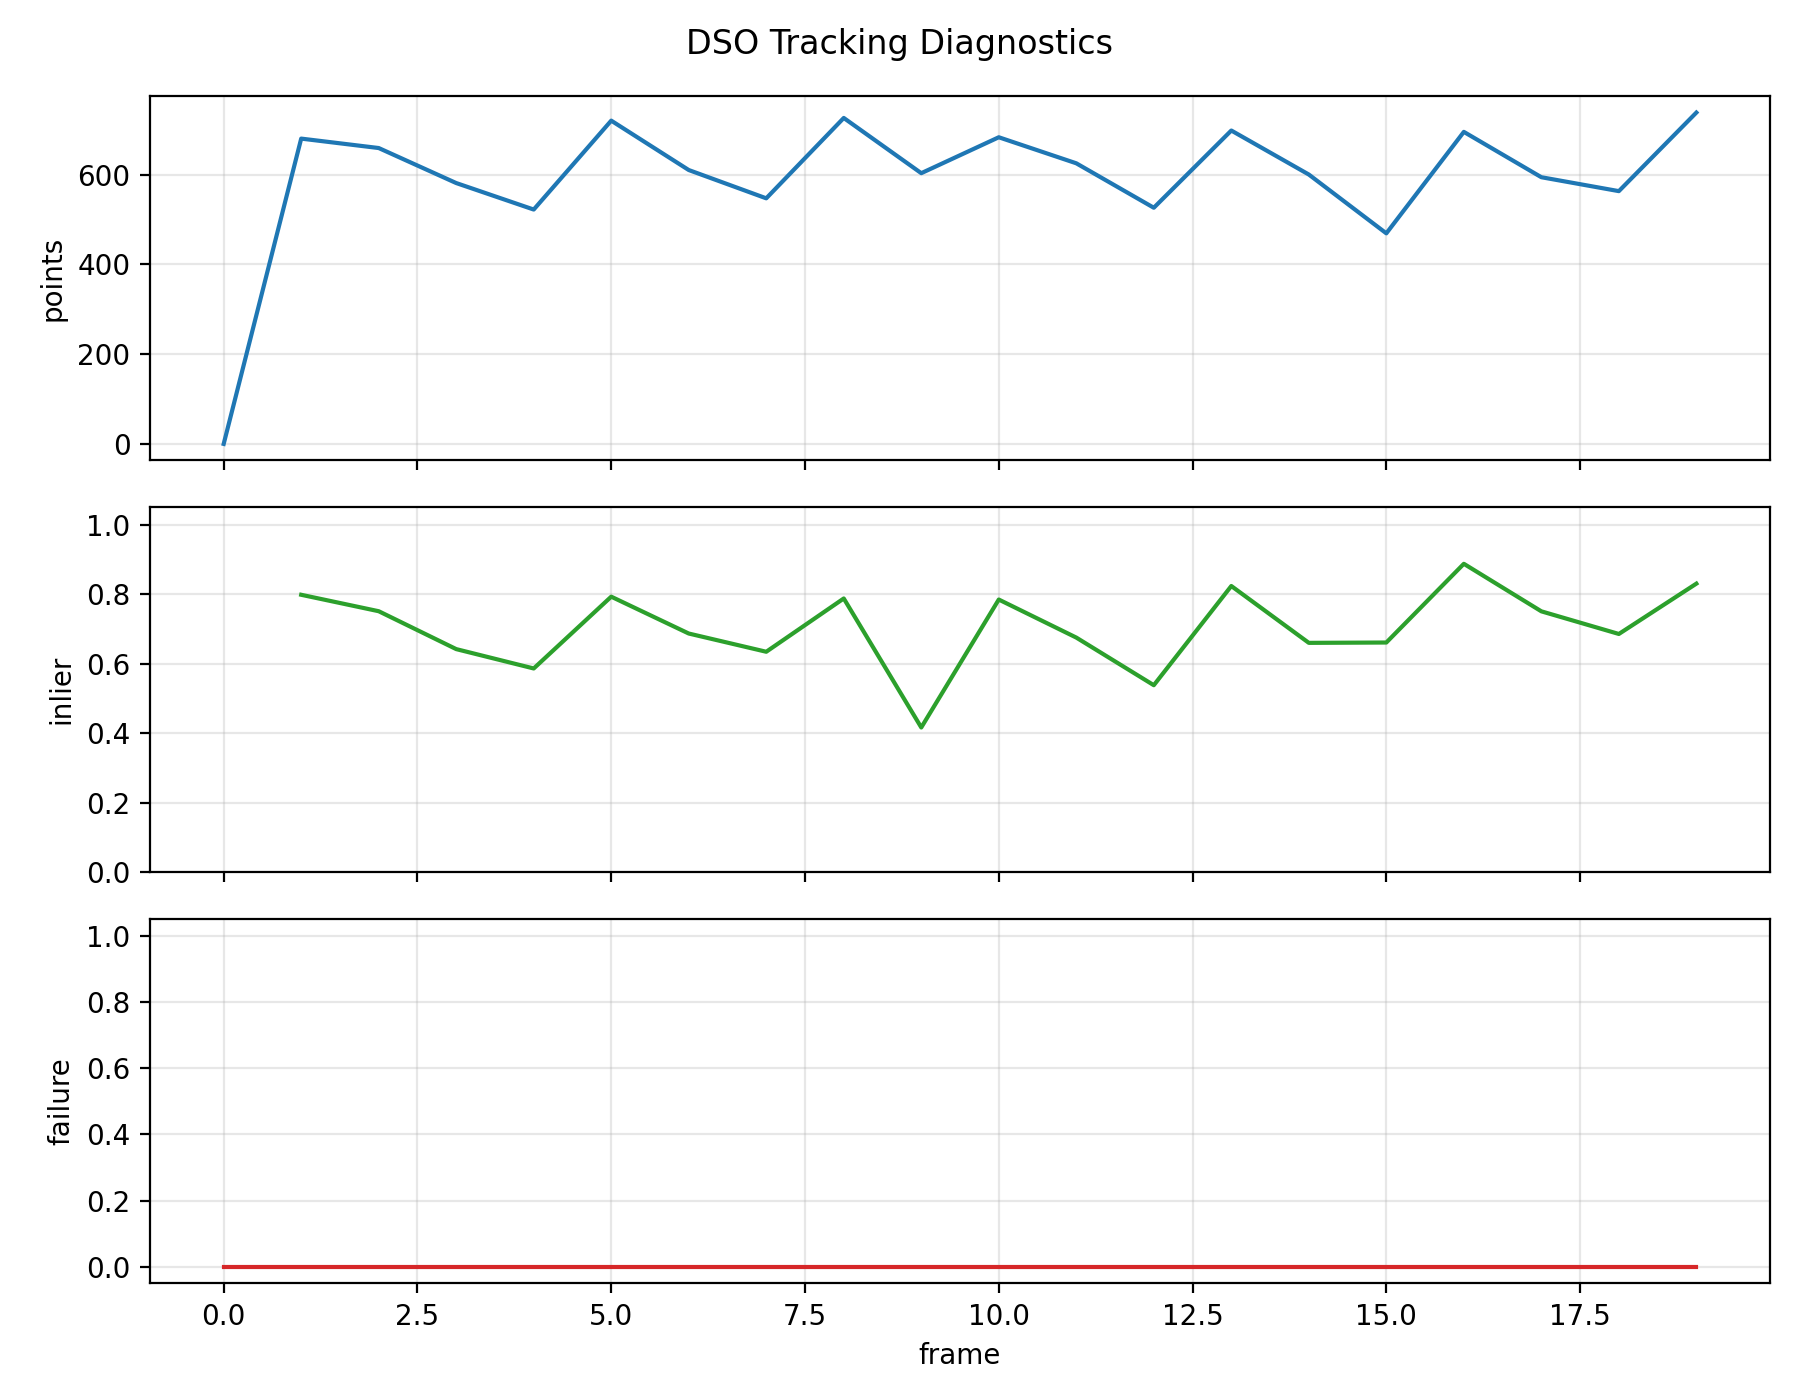

### `results\tri_slam_100\benchmark_trajectory_seq00.png`

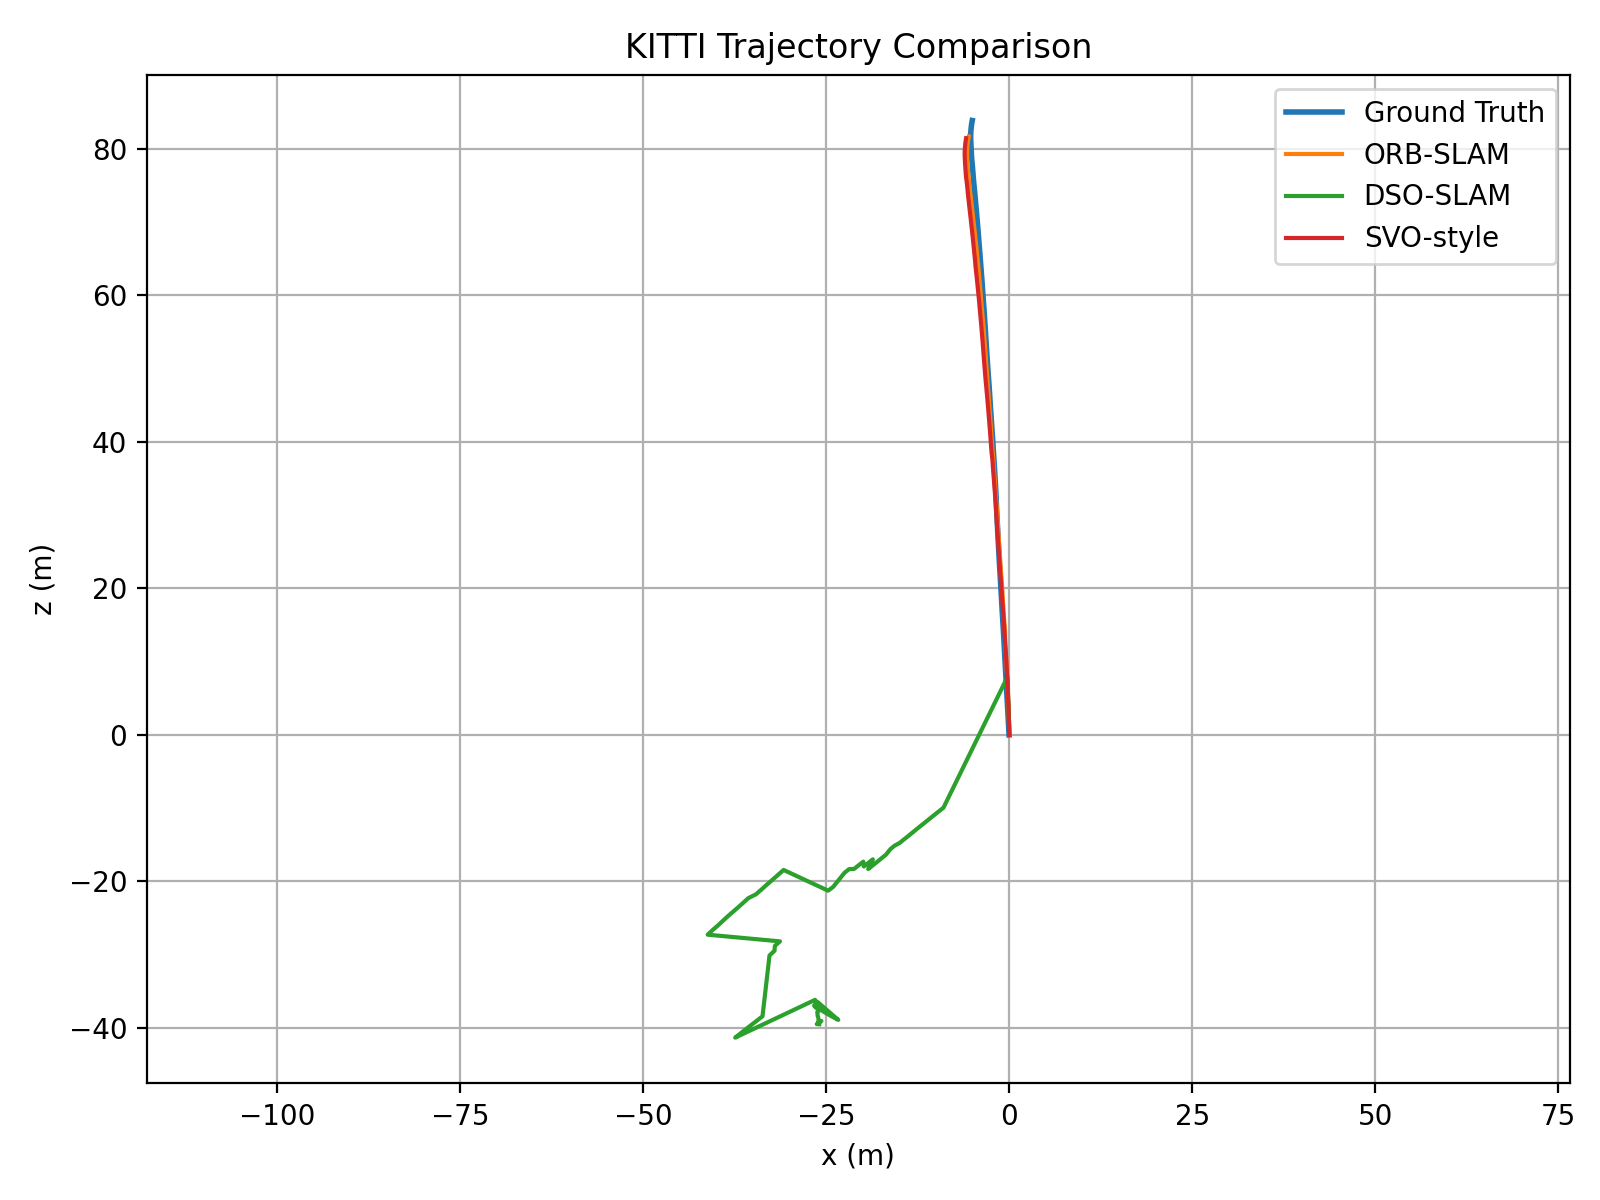

### `results\tri_slam_100\dso_diagnostics_seq00.png`

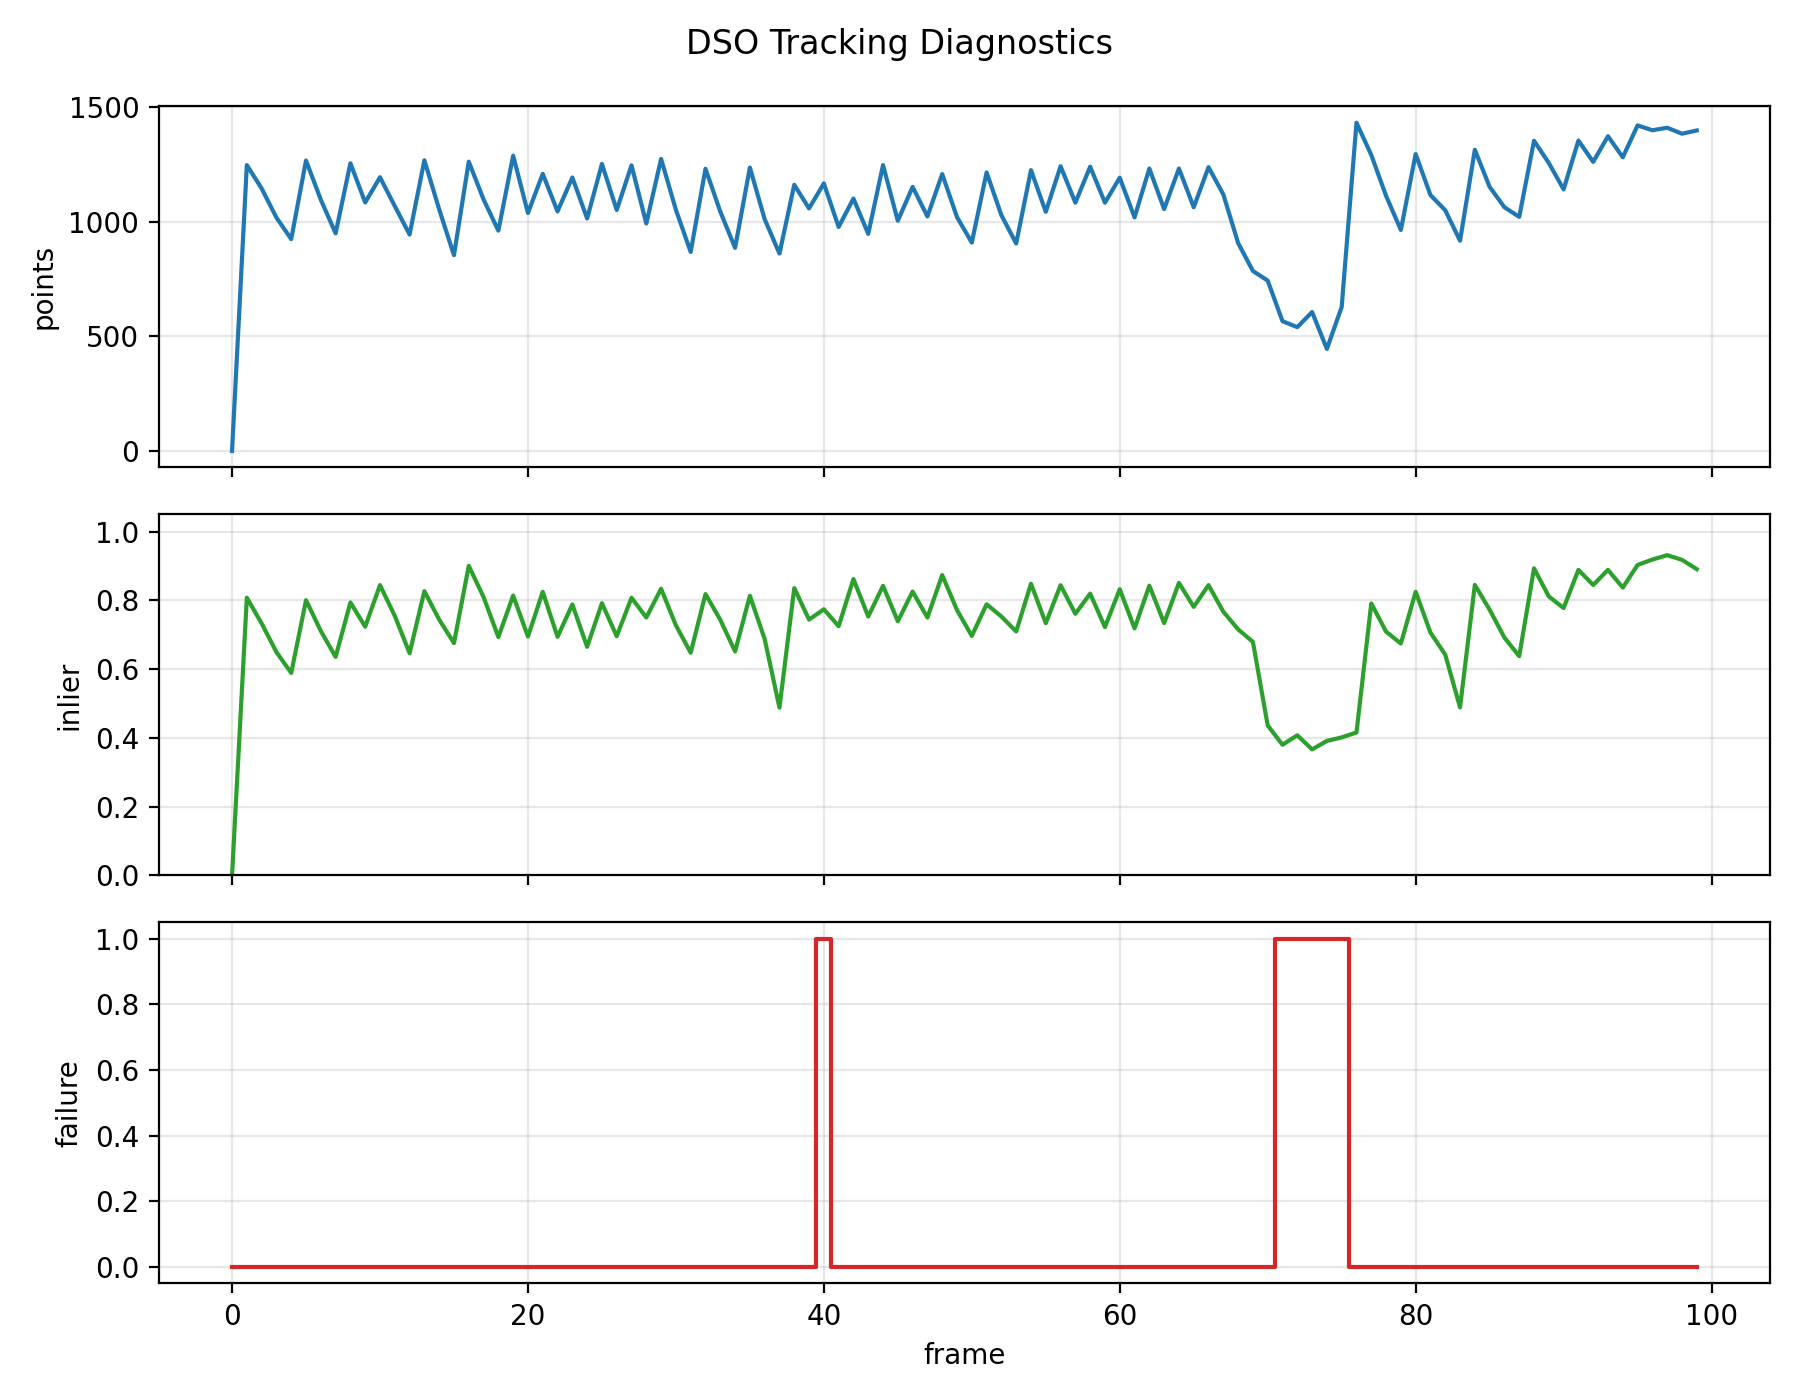

In [12]:
image_paths = [
    RESULTS / 'tri_slam_20' / 'benchmark_trajectory_seq00.png',
    RESULTS / 'tri_slam_20' / 'dso_diagnostics_seq00.png',
    RESULTS / 'tri_slam_100' / 'benchmark_trajectory_seq00.png',
    RESULTS / 'tri_slam_100' / 'dso_diagnostics_seq00.png',
]

for path in image_paths:
    if path.exists():
        display(Markdown(f'### `{path}`'))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f'Missing image: `{path}`'))


## 6. DSO Ablation

The ablation output helps compare LK+PnP, photometric refinement, motion gating, grid-uniform selection, and outlier culling.


### DSO ablation, Sequence 00, max_frames=100, points=1500

| Config | ATE RMSE (m) | Tracking failures | Fallbacks | Motion gate rejects | Mean valid points | Mean inlier ratio | Runtime avg (ms) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| full_simplified_dso | 40.0404 | 1 | 1 | 0 | 1113.22 | 0.7338 | 734.29 |
| lk_pnp_only | 77.2572 | 0 | 0 | 0 | 1115.00 | 0.6717 | 616.25 |
| photometric_with_motion_gate | 75.7913 | 17 | 17 | 10 | 1346.86 | 0.4826 | 534.43 |
| grid_uniform_selection | 11.6835 | 1 | 1 | 0 | 1113.49 | 0.7381 | 836.57 |
| outlier_culling_on | 9.5661 | 14 | 14 | 10 | 1361.77 | 0.4819 | 593.63 |
| outlier_culling_off | 75.7913 | 17 | 17 | 10 | 1346.86 | 0.4826 | 535.78 |

### `results\dso_ablation_100\dso_ablation_seq00.png`

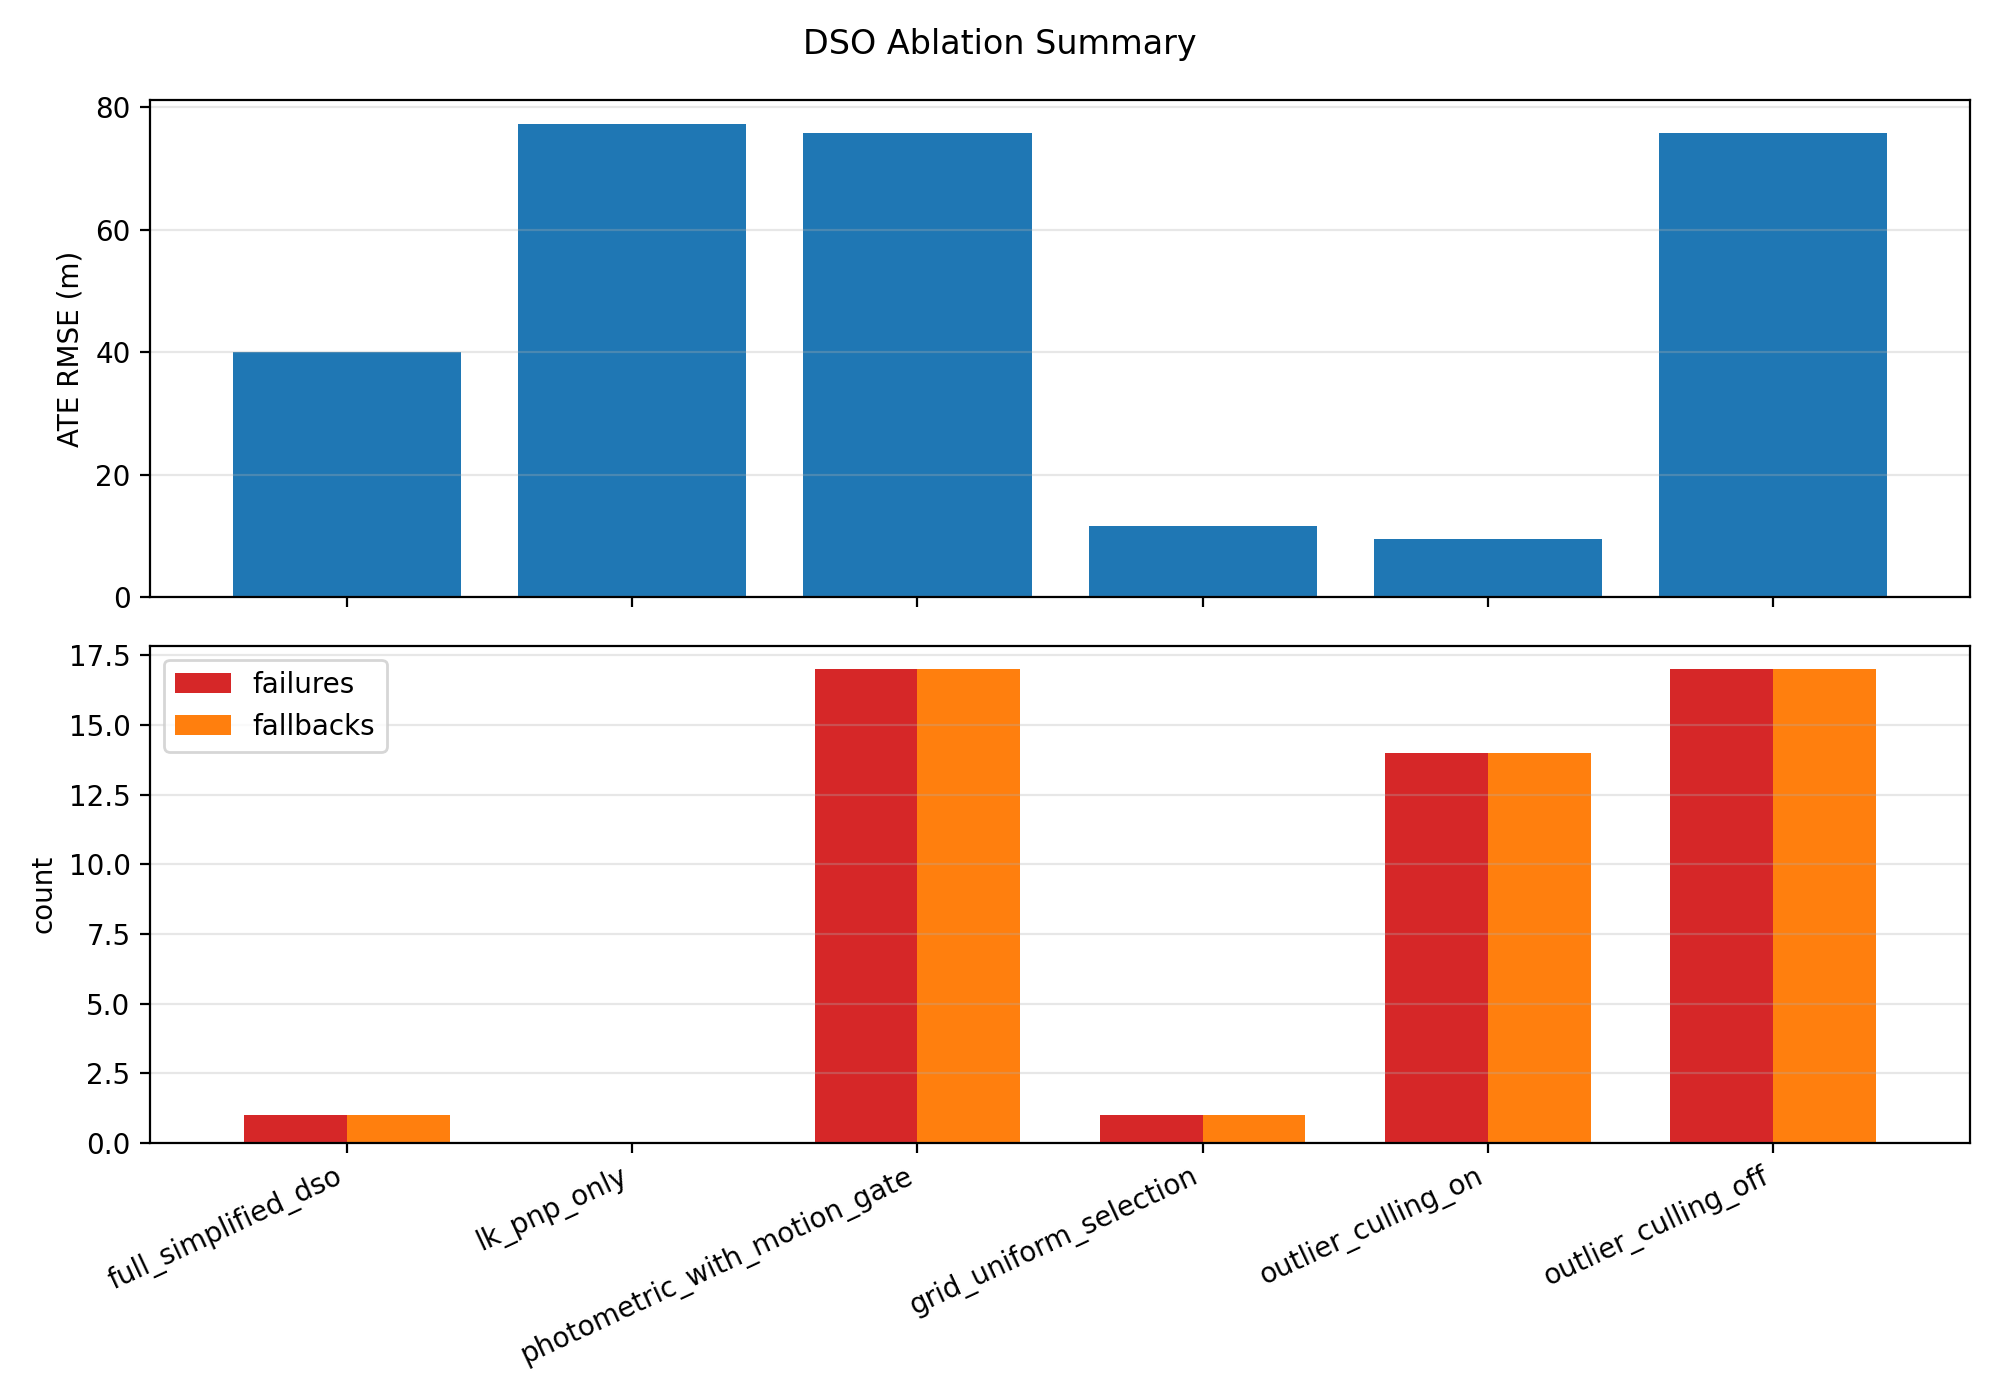

In [13]:
ablation = load_json(ABLATION_PATH)
rows = []
for name, item in ablation['configs'].items():
    robust = item.get('robustness', {})
    runtime = item.get('runtime', {})
    rows.append([
        name,
        fmt(item.get('ate_rmse_m')),
        fmt(robust.get('tracking_failures'), 0),
        fmt(robust.get('fallbacks_used'), 0),
        fmt(robust.get('motion_gate_rejections'), 0),
        fmt(robust.get('mean_valid_projected_points'), 2),
        fmt(robust.get('mean_inlier_ratio'), 4),
        fmt(runtime.get('avg_ms'), 2),
    ])

headers = [
    'Config',
    'ATE RMSE (m)',
    'Tracking failures',
    'Fallbacks',
    'Motion gate rejects',
    'Mean valid points',
    'Mean inlier ratio',
    'Runtime avg (ms)',
]

display(Markdown(f'### DSO ablation, Sequence {ablation["sequence"]}, max_frames={ablation["max_frames"]}, points={ablation["points"]}'))
display(Markdown(markdown_table(headers, rows)))

plot_path = RESULTS / 'dso_ablation_100' / 'dso_ablation_seq00.png'
if plot_path.exists():
    display(Markdown(f'### `{plot_path}`'))
    display(Image(filename=str(plot_path)))


## 7. Optional: Re-run Experiments

The cell below prints the canonical commands. Set `RUN_BENCHMARKS = True` only when you really want to re-run them. The 100-frame ORB run can be slow.


In [14]:
import subprocess
import sys

RUN_BENCHMARKS = False

commands = [
    [sys.executable, '-B', 'run_benchmark.py', '--data-dir', 'data/kitti_odometry', '--seq', '00', '--max-frames', '20', '--algorithms', 'orb,dso,svo', '--features', '800', '--points', '800', '--svo-points', '1500', '--output-dir', 'results/tri_slam_20'],
    [sys.executable, '-B', 'run_benchmark.py', '--data-dir', 'data/kitti_odometry', '--seq', '00', '--max-frames', '100', '--algorithms', 'orb,dso,svo', '--features', '1500', '--points', '1500', '--svo-points', '1500', '--output-dir', 'results/tri_slam_100'],
    [sys.executable, '-B', 'dso_ablation.py', '--data-dir', 'data/kitti_odometry', '--seq', '00', '--max-frames', '100', '--points', '1500', '--output-dir', 'results/dso_ablation_100'],
]

if RUN_BENCHMARKS:
    for cmd in commands:
        print(' '.join(cmd))
        subprocess.run(cmd, check=True)
else:
    for cmd in commands:
        print(' '.join(cmd))


d:\Project\2-MashineLearning\.venv\Scripts\python.exe -B run_benchmark.py --data-dir data/kitti_odometry --seq 00 --max-frames 20 --algorithms orb,dso,svo --features 800 --points 800 --svo-points 1500 --output-dir results/tri_slam_20
d:\Project\2-MashineLearning\.venv\Scripts\python.exe -B run_benchmark.py --data-dir data/kitti_odometry --seq 00 --max-frames 100 --algorithms orb,dso,svo --features 1500 --points 1500 --svo-points 1500 --output-dir results/tri_slam_100
d:\Project\2-MashineLearning\.venv\Scripts\python.exe -B dso_ablation.py --data-dir data/kitti_odometry --seq 00 --max-frames 100 --points 1500 --output-dir results/dso_ablation_100


## 8. Current Takeaways and Limitations

- The 20-frame smoke benchmark produces length-aligned ORB, DSO, and SVO trajectories.
- In the 100-frame benchmark, SVO-style and ORB-inspired remain close in ATE, while DSO-inspired shows strong drift and several fallbacks.
- The 100-frame ORB runtime has an extreme long tail; re-run or profile it before using it as a final runtime conclusion.
- Short runs may not contain enough 100m KITTI path segments, so RPE and KITTI segment metrics can be `null`.
- SVO-style does not implement production-grade loop closure; DSO-inspired is not full joint photometric BA with Schur-complement marginalization.
